# IQAir Purifier Sensor Check
To determine if purifier fan activation has a substantial impact on purifier-embedded temperature / PM2.5 measurements

In [74]:
source("../util/packages.R")
source("../util/variables.R")
source("../util/plot_helpers.R")
source("../util/add_treatment_to_df.R")
source("../util/fan_on_helpers.R")

dimension <- plot_dimension(is_vertical = FALSE)
options(repr.plot.width = dimension$width, repr.plot.height = dimension$height)

Rows: 221 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): purifier_group, first_or_second_half, treatment, treatment_boundary
dbl  (2): period_id, treatment_order
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### 1. Real vs Placebo filters during the study

In [75]:
ALL_PARTICIPANTS_METADATA <- read_rds("../R-table/ALL_PARTICIPANTS_METADATA.rds")
ALL_PURIFIERS_DATA <- read_rds("../R-table/ALL_PURIFIERS_DATA.rds")

PURIFIER_AND_PARTICIPANT_DATA <- add_treatment_to_df(
  data = ALL_PURIFIERS_DATA  |>
          left_join(
            ALL_PARTICIPANTS_METADATA,
            by = "purifier_id"
          ),
  only_during_intervention = FALSE
) |> filter(treatment != "washout") |>
  select(pseudonym, treatment, treatment_boundary, start_date, pm25, temperature, is_fan_on)

head(PURIFIER_AND_PARTICIPANT_DATA)

Warning message in left_join(ALL_PURIFIERS_DATA, ALL_PARTICIPANTS_METADATA, by = "purifier_id"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 4 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


pseudonym,treatment,treatment_boundary,start_date,pm25,temperature,is_fan_on
<chr>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<lgl>
carrot7,treatment1,before_start_first_half,2025-02-16 03:03:00,10,22.0,FALSE
carrot7,treatment1,before_start_first_half,2025-02-16 03:04:00,10,21.9,FALSE
carrot7,treatment1,before_start_first_half,2025-02-16 03:11:00,10,21.9,FALSE
carrot7,treatment1,before_start_first_half,2025-02-16 03:16:00,10,21.9,FALSE
carrot7,treatment1,before_start_first_half,2025-02-16 03:21:00,10,21.9,FALSE
carrot7,treatment1,before_start_first_half,2025-02-16 03:26:00,10,21.9,FALSE


In [76]:
study_raw <- PURIFIER_AND_PARTICIPANT_DATA |>
  filter(
    treatment_boundary %in% c(
      "before_start_first_half",
      "before_start_second_half",
      "start_second_half"
    )
  )

study_events <- detect_fan_on_events(
  data = study_raw,
  id_cols = c("pseudonym", "treatment")
)

study_event_rows <- attach_measurements_to_events(
  data = study_raw,
  events = study_events,
  id_cols = c("pseudonym", "treatment"),
  before_minutes = BEFORE_FAN_ON_MINUTES,
  after_minutes = AFTER_FAN_ON_MINUTES
)

### 1.1. Temperature Change

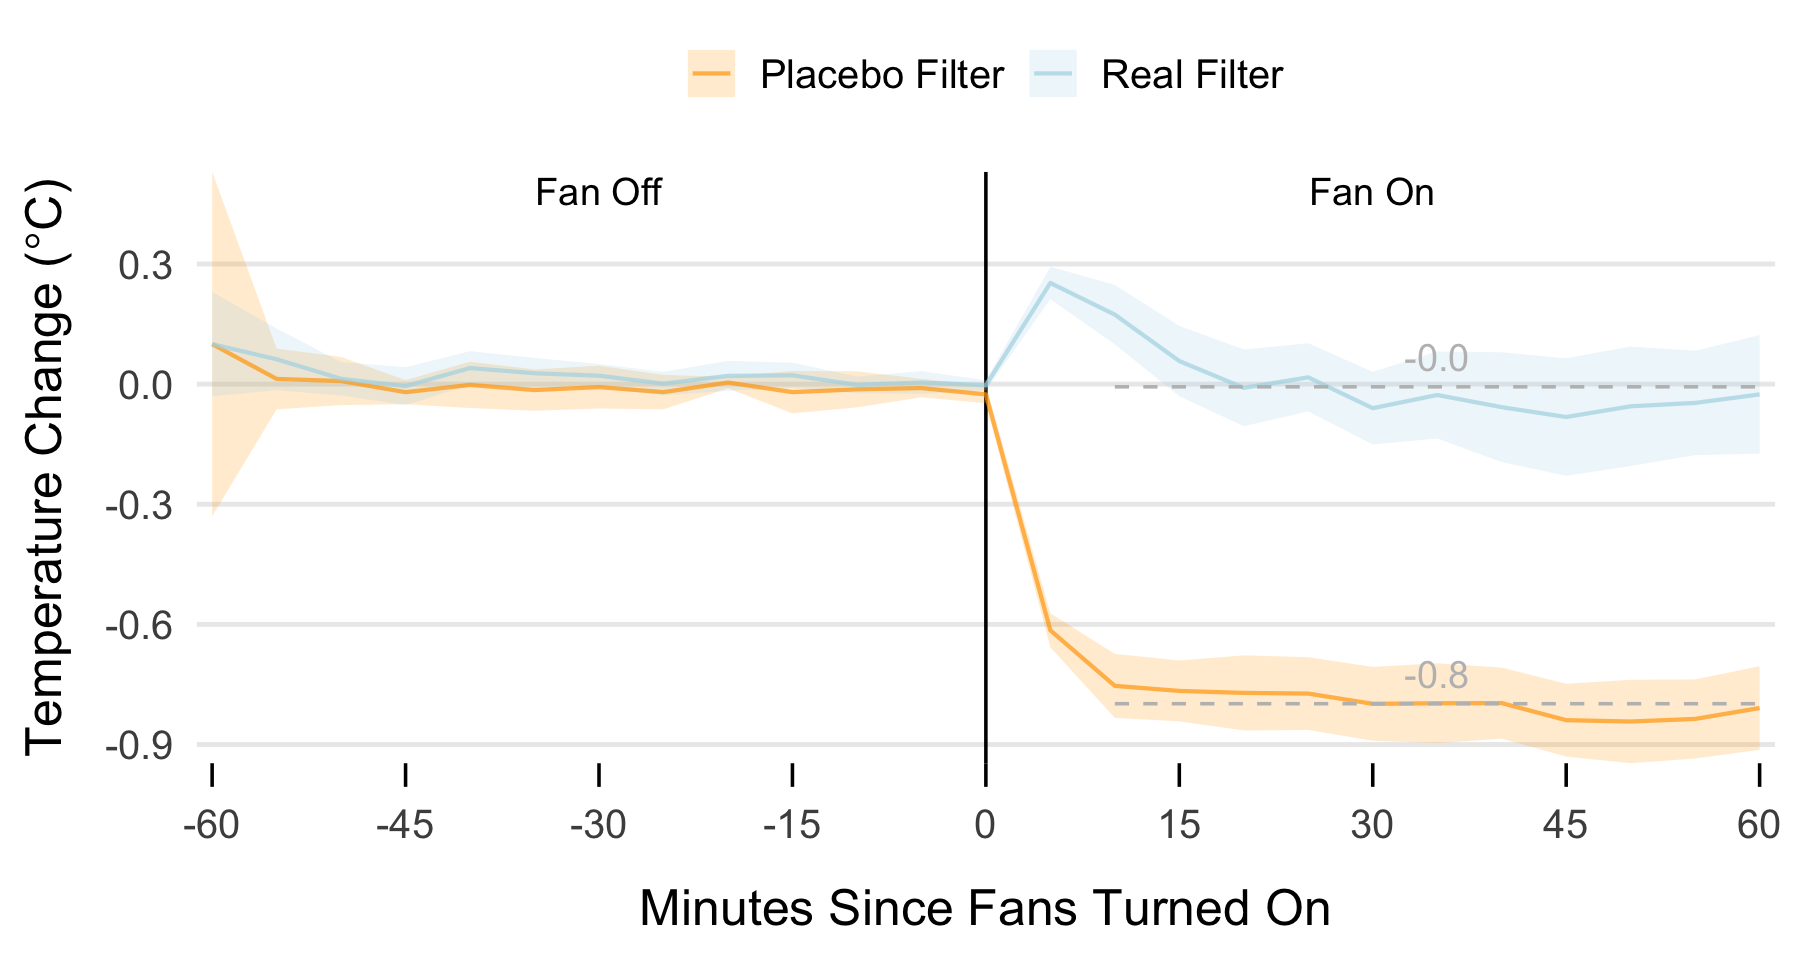

In [77]:
study_temperature_events <- prepare_fan_metric(
  event_rows = study_event_rows,
  id_cols = c("pseudonym", "treatment"),
  value_cols = "temperature",
  bin_minutes = AGGREGATION_MINUTES
)

plot_fan_on(
  df = study_temperature_events,
  x = "relative_bin_start",
  y = "delta_temperature",
  group = "treatment",
  ylabel = expression("Temperature Change (" * degree * C * ")"),
  yBreaks = c(-0.9, -0.6, -0.3, 0.0, 0.3, 0.6, 0.9),
  minute_mark_to_calc_avg = 10,
  fileName = "temperature_real_placebo.pdf"
)

In [78]:
temp_corrections <- study_temperature_events |> 
  group_by(treatment) |> 
  filter(relative_bin_start >= 10) |> 
  summarize(mean_temp_diff = round(mean(delta_temperature, na.rm = TRUE), 1))

temp_corrections

treatment,mean_temp_diff
<chr>,<dbl>
treatment1,-0.8
treatment2,0.0


### 1.2. PM2.5 Change

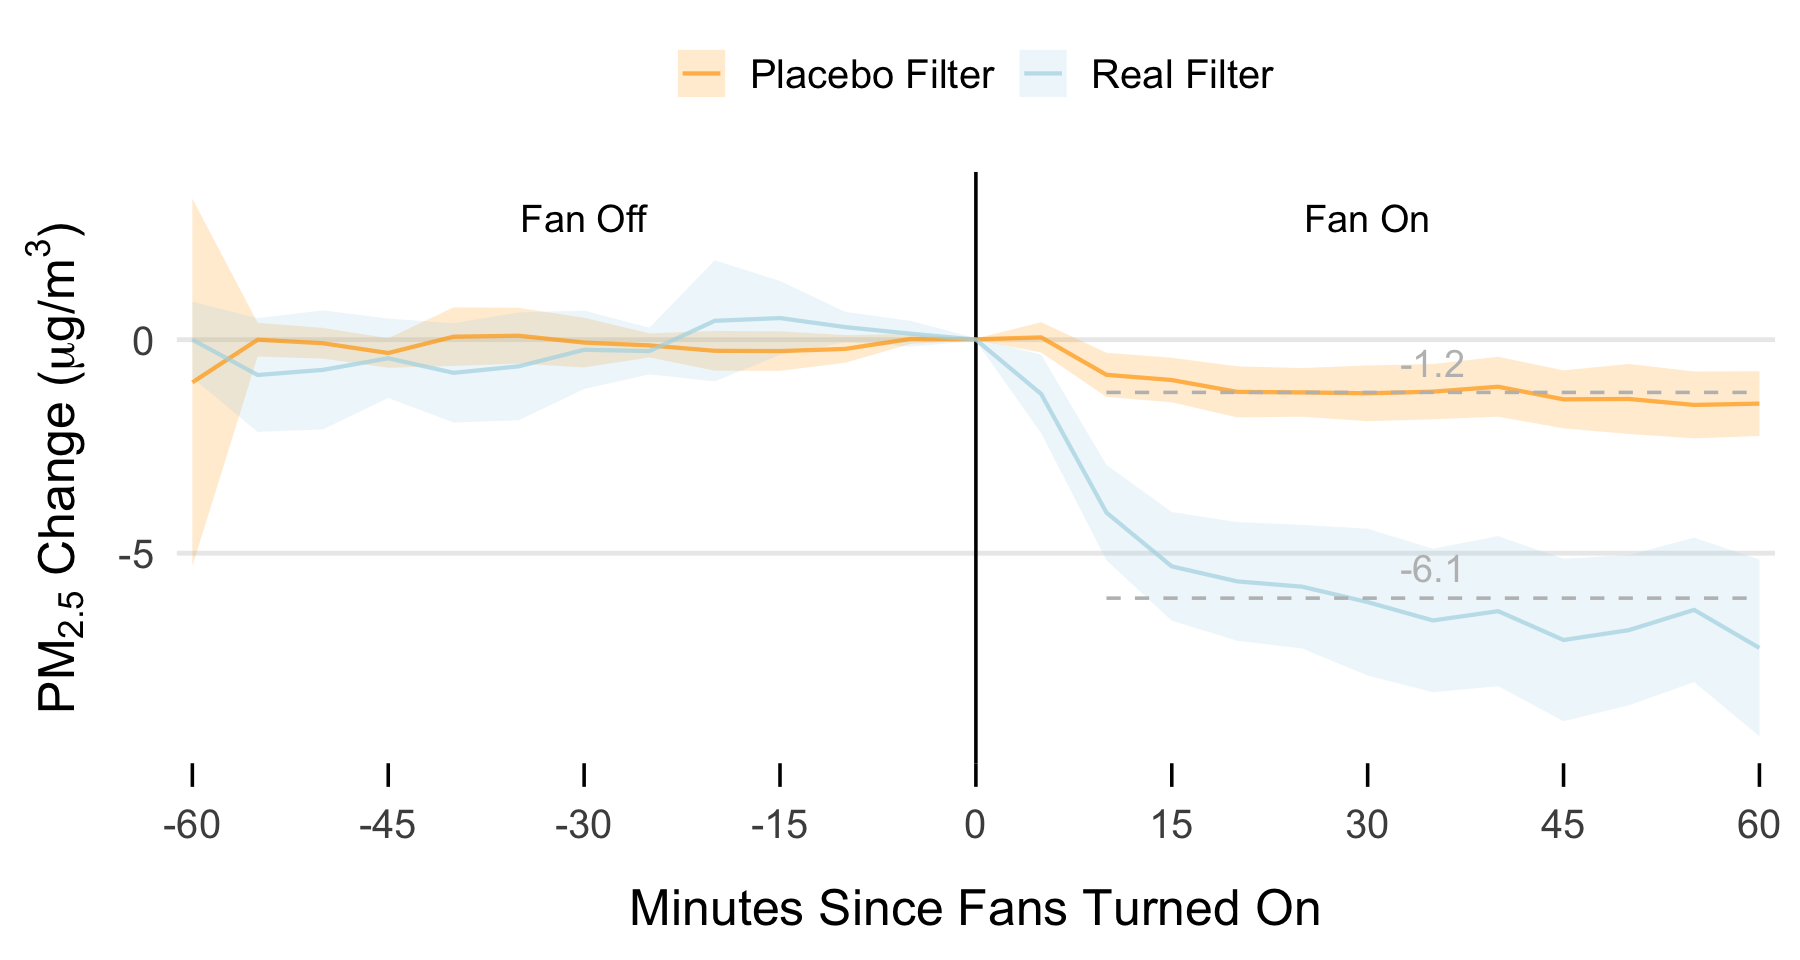

In [79]:
study_pm25_events <- prepare_fan_metric(
  event_rows = study_event_rows,
  id_cols = c("pseudonym", "treatment"),
  value_cols = "pm25",
  bin_minutes = AGGREGATION_MINUTES
)

plot_fan_on(
    df = study_pm25_events,
    x = "relative_bin_start",
    y = "delta_pm25",
    group = "treatment",
    ylabel = expression("PM"[2.5] * " Change (" * mu * "g/m"^3 * ")"),
    minute_mark_to_calc_avg = 10,
    fileName = "pm25_real_placebo.pdf"
)

### 2. PM2.5 comparison when fans run without filter
A subset of 5/14 purifiers used in the study, comparing before and after turning on the fan (30-minute periods)

In [80]:
ALL_PURIFIERS_NO_FILTER_DATA <- map_dfr(
  list.files(file.path("../raw-data/iqair-purifiers/no-filter"), pattern = "\\.csv$", full.names = TRUE),
  function(file_path) {
    read_csv(file_path, col_types = cols()) |>
      rename_with(~ str_trim(.)) |>
      mutate(
        start_date = as.POSIXct(start_date, format = "%m/%d/%Y %H:%M", tz = "GMT") + hours(4),
      ) |>
      select(purifier_id, start_date, pm25, is_fan_on)
  }
) |>
  filter(pm25 > 0) |>
  group_by(purifier_id, start_date) |>
  summarise(
    pm25 = mean(pm25, na.rm = TRUE),
    is_fan_on = last(is_fan_on),
    .groups = "drop"
  )

head(ALL_PURIFIERS_NO_FILTER_DATA, n = 5)

purifier_id,start_date,pm25,is_fan_on
<chr>,<dttm>,<dbl>,<lgl>
040p-g00a-llf0-8,2026-06-29 16:57:00,11,FALSE
040p-g00a-llf0-8,2026-06-29 16:58:00,12,FALSE
040p-g00a-llf0-8,2026-06-29 17:01:00,12,FALSE
040p-g00a-llf0-8,2026-06-29 17:02:00,12,FALSE
040p-g00a-llf0-8,2026-06-29 17:04:00,12,FALSE


In [81]:
no_filter_events <- detect_fan_on_events(
  data = ALL_PURIFIERS_NO_FILTER_DATA,
  id_cols = "purifier_id",
  validation_minutes = 30,
  max_transition_gap_minutes = 15
)

no_filter_event_rows <- attach_measurements_to_events(
  data = ALL_PURIFIERS_NO_FILTER_DATA,
  events = no_filter_events,
  id_cols = "purifier_id",
  before_minutes = 30,
  after_minutes = 30
)

In [82]:
no_filter_pm25_events <- prepare_fan_metric(
  event_rows = no_filter_event_rows,
  id_cols = "purifier_id",
  value_cols = "pm25",
  bin_minutes = AGGREGATION_MINUTES
)

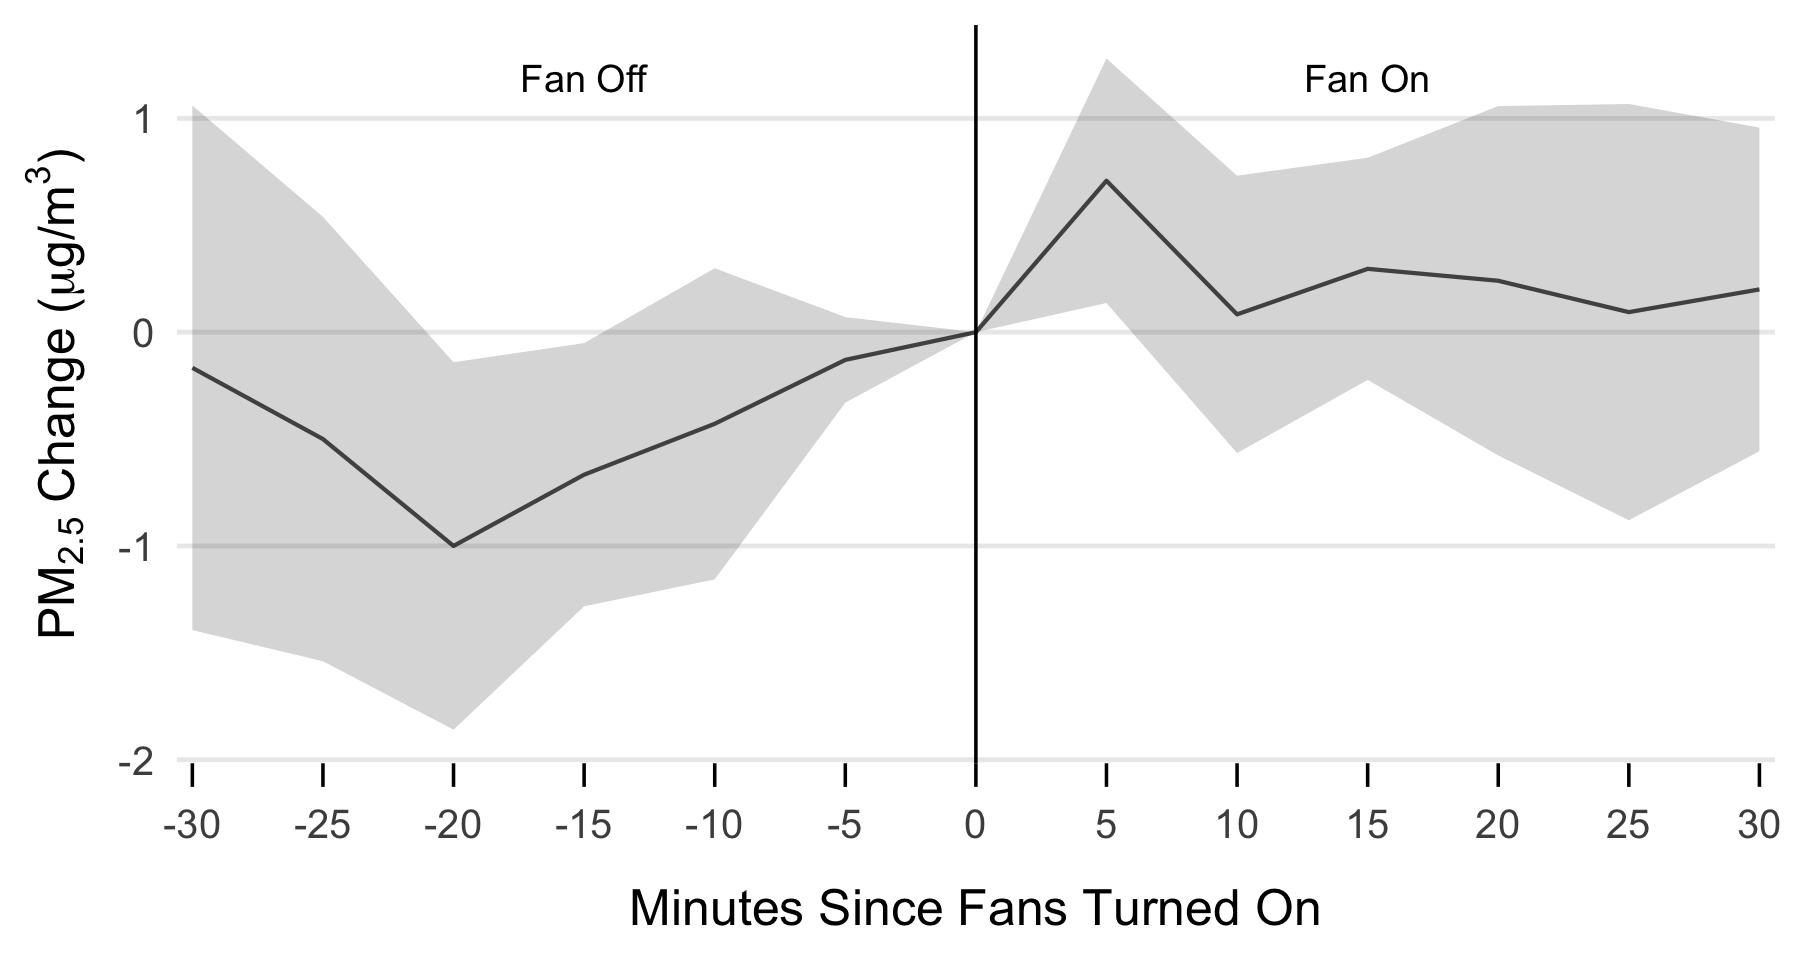

In [83]:
plot_fan_on(
  df = no_filter_pm25_events,
  x = "relative_bin_start",
  y = "delta_pm25",
  ylabel = expression("PM"[2.5] * " Change (" * mu * "g/m"^3 * ")"),
  fileName = "pm25_no_filter.pdf"
)

### 3. PM2.5 comparison when fans run with real filter (colocation with PurpleAir Zen)
(conducted in another study)

In [84]:
metadata <- read_csv(
  "../raw-data/iqair-purpleair-colocation/metadata.csv",
  col_types = cols(
    purpleair = col_character(),
    iqair = col_character()
  )
) |>
  rename(
    sensor_id = purpleair,
    purifier_id = iqair
  )
metadata

sensor_id,purifier_id
<chr>,<chr>
265505,040p-g007-3lf0-8
265239,040p-g008-6lf0-8
265029,040p-g008-5lf0-8
265517,040p-g008-3lf0-8
265235,040p-g008-7lf0-8
265261,040p-g008-8lf0-8
265509,040p-g008-2lf0-8


In [85]:
csv_files <- list.files(
  "../raw-data/iqair-purpleair-colocation/iqair-purifiers",
  pattern = "\\.csv$",
  full.names = TRUE
)

iqair_data <- map_dfr(csv_files, function(f) {
  read.csv(f, check.names = FALSE)
})

iqair_data <- iqair_data |>
  mutate(
    start_date = as.POSIXct(
      start_date,
      format = "%Y-%m-%dT%H:%M:%S",
      tz = "GMT"
    ) + hours(4),
    .after = purifier_id,
    pm25_iqair = pm25
  ) |>
  filter(!is.na(pm25)) |>
  select(purifier_id, start_date, pm25_iqair, is_fan_on)

head(iqair_data)

,purifier_id,start_date,pm25_iqair,is_fan_on
,<chr>,<dttm>,<int>,<lgl>
1,040p-g007-3lf0-8,2025-03-14 10:07:00,10,TRUE
2,040p-g007-3lf0-8,2025-03-14 10:07:00,24,TRUE
3,040p-g007-3lf0-8,2025-03-14 10:08:00,23,TRUE
4,040p-g007-3lf0-8,2025-03-14 10:09:00,22,TRUE
5,040p-g007-3lf0-8,2025-03-14 10:10:00,24,TRUE
6,040p-g007-3lf0-8,2025-03-14 10:11:00,23,TRUE


In [86]:
purpleair_data <- list.files(
  path = "../raw-data/iqair-purpleair-colocation/purpleair-sensors",
  pattern = "\\.csv$",
  full.names = TRUE,
) |>
  map_dfr(function(file) {
    filename <- tools::file_path_sans_ext(basename(file))

    read_csv(
      file,
      col_types = cols(
        start_date = col_character(),
        pm25 = col_double()
      ),
      show_col_types = FALSE
    ) |>
      mutate(
        sensor_id = sub("\\s.*$", "", filename)
      )
  }) |>
  filter(!is.na(pm25)) |>
  mutate(
    start_date = as.POSIXct(
      start_date,
      format = "%Y-%m-%dT%H:%M:%S",
      tz = "GMT"
    ) + hours(4),
    pm25_purpleair = pm25
  ) |>
  inner_join(
    metadata, by = c("sensor_id")
  ) |> select(purifier_id, start_date, pm25_purpleair)
  
head(purpleair_data)

purifier_id,start_date,pm25_purpleair
<chr>,<dttm>,<dbl>
040p-g008-5lf0-8,2025-03-17 00:01:44,54.2
040p-g008-5lf0-8,2025-03-17 00:03:44,54.1
040p-g008-5lf0-8,2025-03-17 00:05:44,55.3
040p-g008-5lf0-8,2025-03-17 00:07:44,54.1
040p-g008-5lf0-8,2025-03-17 00:09:44,54.1
040p-g008-5lf0-8,2025-03-17 00:11:44,55.3


In [87]:
fan_on_events <- detect_fan_on_events(
  data = iqair_data,
  id_cols = "purifier_id"
)
head(fan_on_events)

iqair_event_rows <- attach_measurements_to_events(
  data = iqair_data,
  events = fan_on_events,
  id_cols = "purifier_id"
)
head(iqair_event_rows)

purpleair_event_rows <- attach_measurements_to_events(
  data = purpleair_data,
  events = fan_on_events,
  id_cols = "purifier_id"
)
head(purpleair_event_rows)

purifier_id,event_id,event_number,event_time
<chr>,<chr>,<int>,<dttm>
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00
040p-g007-3lf0-8,1__2,2,2025-03-17 06:00:00
040p-g007-3lf0-8,1__4,4,2025-03-18 06:00:00
040p-g007-3lf0-8,1__5,5,2025-03-19 06:00:00
040p-g007-3lf0-8,1__6,6,2025-03-20 06:00:00
040p-g007-3lf0-8,1__7,7,2025-03-21 06:00:00


purifier_id,event_id,event_number,event_time,start_date,pm25_iqair,is_fan_on,minutes_from_fan_on
<chr>,<chr>,<int>,<dttm>,<dttm>,<int>,<lgl>,<dbl>
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,2025-03-15 10:11:00,26,FALSE,-58
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,2025-03-15 10:13:00,29,FALSE,-56
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,2025-03-15 10:23:00,28,FALSE,-46
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,2025-03-15 10:33:00,27,FALSE,-36
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,2025-03-15 10:43:00,29,FALSE,-26
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,2025-03-15 10:44:00,29,FALSE,-25


purifier_id,event_id,event_number,event_time,start_date,pm25_purpleair,minutes_from_fan_on
<chr>,<chr>,<int>,<dttm>,<dttm>,<dbl>,<dbl>
040p-g007-3lf0-8,1__2,2,2025-03-17 06:00:00,2025-03-17 05:01:03,41.7,-58.95000
040p-g007-3lf0-8,1__2,2,2025-03-17 06:00:00,2025-03-17 05:03:04,42.2,-56.93333
040p-g007-3lf0-8,1__2,2,2025-03-17 06:00:00,2025-03-17 05:05:03,42.1,-54.95000
040p-g007-3lf0-8,1__2,2,2025-03-17 06:00:00,2025-03-17 05:07:03,42.1,-52.95000
040p-g007-3lf0-8,1__2,2,2025-03-17 06:00:00,2025-03-17 05:09:04,42.4,-50.93333
040p-g007-3lf0-8,1__2,2,2025-03-17 06:00:00,2025-03-17 05:11:03,42.0,-48.95000


In [88]:
iqair_event_bins <- prepare_fan_metric(
  event_rows = iqair_event_rows,
  id_cols = "purifier_id",
  value_cols = "pm25_iqair",
  bin_minutes = AGGREGATION_MINUTES
)
head(iqair_event_bins)

purpleair_event_bins <- prepare_fan_metric(
  event_rows = purpleair_event_rows,
  id_cols = "purifier_id",
  value_cols = "pm25_purpleair",
  bin_minutes = AGGREGATION_MINUTES
)
head(purpleair_event_bins)

purifier_id,event_id,event_number,event_time,relative_bin_start,relative_bin_end,pm25_iqair,n_pm25_iqair,mean_measurement_minute,baseline_pm25_iqair,delta_pm25_iqair
<chr>,<chr>,<int>,<dttm>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,-55,-50,27.5,1,-57.0,27,0.5
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,-45,-40,28.0,1,-46.0,27,1.0
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,-35,-30,27.0,1,-36.0,27,0.0
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,-25,-20,29.0,1,-25.5,27,2.0
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,-20,-15,29.0,1,-23.0,27,2.0
040p-g007-3lf0-8,1__1,1,2025-03-15 11:09:00,-15,-10,28.5,1,-17.0,27,1.5


purifier_id,event_id,event_number,event_time,relative_bin_start,relative_bin_end,pm25_purpleair,n_pm25_purpleair,mean_measurement_minute,baseline_pm25_purpleair,delta_pm25_purpleair
<chr>,<chr>,<int>,<dttm>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-55,-50,2.000000,1,-57.60556,2.2,-0.2000000
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-50,-45,2.850000,1,-52.60000,2.2,0.6500000
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-45,-40,2.633333,1,-47.61111,2.2,0.4333333
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-40,-35,2.700000,1,-42.61667,2.2,0.5000000
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-35,-30,2.500000,1,-37.61111,2.2,0.3000000
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-30,-25,2.750000,1,-32.60833,2.2,0.5500000


In [89]:
colocation_event_bins <- iqair_event_bins |>
  select(
    purifier_id,
    event_id,
    event_number,
    event_time,
    relative_bin_start,
    relative_bin_end,
    pm25_iqair,
    baseline_pm25_iqair,
    delta_pm25_iqair,
    n_pm25_iqair,
    mean_measurement_minute_iqair =
      mean_measurement_minute
  ) |>
  inner_join(
    purpleair_event_bins |>
      select(
        purifier_id,
        event_id,
        relative_bin_start,
        pm25_purpleair,
        baseline_pm25_purpleair,
        delta_pm25_purpleair,
        n_pm25_purpleair,
        mean_measurement_minute_purpleair =
          mean_measurement_minute
      ),
    by = c(
      "purifier_id",
      "event_id",
      "relative_bin_start"
    )
  ) |>
  mutate(
    differential_change =
      delta_pm25_iqair -
      delta_pm25_purpleair,

    within_bin_timing_difference = abs(
      mean_measurement_minute_iqair -
      mean_measurement_minute_purpleair
    )
  )

head(colocation_event_bins)

purifier_id,event_id,event_number,event_time,relative_bin_start,relative_bin_end,pm25_iqair,baseline_pm25_iqair,delta_pm25_iqair,n_pm25_iqair,mean_measurement_minute_iqair,pm25_purpleair,baseline_pm25_purpleair,delta_pm25_purpleair,n_pm25_purpleair,mean_measurement_minute_purpleair,differential_change,within_bin_timing_difference
<chr>,<chr>,<int>,<dttm>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-55,-50,2.0,2,0.0,1,-56.0,2.000000,2.2,-0.2000000,1,-57.60556,0.2000000,1.605556
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-50,-45,2.5,2,0.5,1,-50.5,2.850000,2.2,0.6500000,1,-52.60000,-0.1500000,2.100000
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-45,-40,3.0,2,1.0,1,-46.0,2.633333,2.2,0.4333333,1,-47.61111,0.5666667,1.611111
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-40,-35,3.0,2,1.0,1,-41.0,2.700000,2.2,0.5000000,1,-42.61667,0.5000000,1.616667
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-35,-30,3.0,2,1.0,1,-36.0,2.500000,2.2,0.3000000,1,-37.61111,0.7000000,1.611111
040p-g007-3lf0-8,1__10,10,2025-04-09 06:00:00,-30,-25,2.5,2,0.5,1,-30.5,2.750000,2.2,0.5500000,1,-32.60833,-0.0500000,2.108333


In [90]:
colocation_room_trajectory <- colocation_event_bins |>
  group_by(
    purifier_id,
    relative_bin_start
  ) |>
  summarise(
    differential_change = mean(
      differential_change,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

head(colocation_room_trajectory)

purifier_id,relative_bin_start,differential_change
<chr>,<dbl>,<dbl>
040p-g007-3lf0-8,-55,0.08166667
040p-g007-3lf0-8,-50,-0.07619048
040p-g007-3lf0-8,-45,0.20000000
040p-g007-3lf0-8,-40,-0.03690476
040p-g007-3lf0-8,-35,0.07333333
040p-g007-3lf0-8,-30,-0.21410256


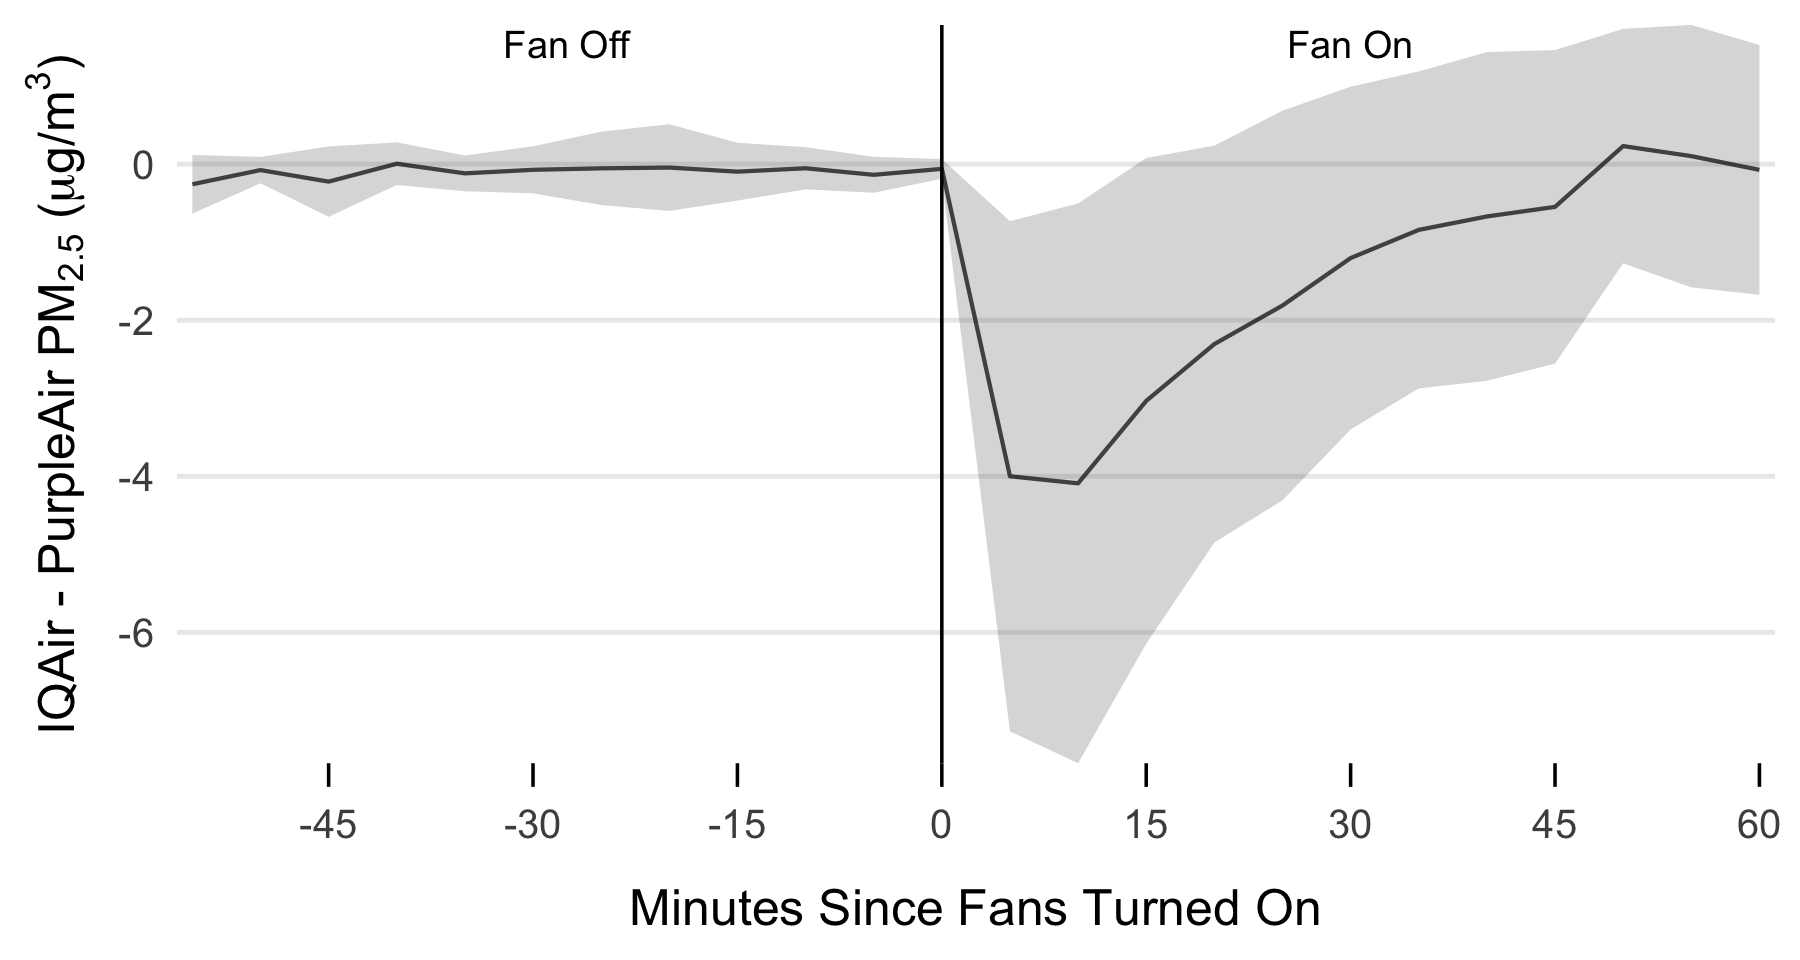

In [91]:
plot_fan_on(
    df = colocation_room_trajectory,
    x = "relative_bin_start",
    y = "differential_change",
    ylabel = expression(
        "IQAir - PurpleAir PM"[2.5] * " (" * mu * "g/m"^3 * ")"
    ),
    yBreaks = c(-6, -4, -2, -0, 2),
    fileName = paste0("pm25_difference_iqair_purpleair_", AGGREGATION_MINUTES, "min.pdf")
)